Now, we can take a break and show how square pulses can cancel $ZZ$ crosstalk (or $XX$, $YY$ crosstalks up to a rotation). We make this claim in the main text and the supplementary material so here we have an example of an $XX$ gate robust to $ZZ$ quasistatic noise to first order. For more dertails, see Section II in Supplementary Material, Eqs. (S20) - (S27).

The geometric condition is given in Eq. (S27) depicting the need for two 3D curves with orthogonal tangent components in the interval $t\in [0,T_g]$. Of course, the same condition is used for the mroe complicated $X_1\otimes Z_2$ gate derived above.

In [ ]:
omega_x1, omega_x2= np.loadtxt("pulses/XX_Square_pulses.csv", delimiter=",").T

t_0_1 = np.linspace(0,1, N_points)


fig = plt.figure(figsize=(5, 5))
plt.plot(t_0_1, omega_x1, label = 'X1 pulse')
plt.plot(t_0_1, omega_x2, label = 'X2 pulse')

plt.xlabel("Time t*χ")
plt.ylabel("Pulse amplitude Ω/χ")
plt.title("XX pulses for cross-talk cancellation")
plt.ylim([0,10])
plt.legend();



Test the crosstalk robustness of the XX gate

In [ ]:
# normalized parameters
x_X1 = omega_x1 * chi                                               # normalized control along X-axis                                       

x_X2 = omega_x2 * chi                                               # normalized control along X-axis                                       

t_XX = np.linspace(0, 1/chi, N_points)                              # gate time


noise_points = 50

ksi = np.logspace(-3,0, noise_points)                               # noise parameter

ksi_over_chi = ksi * chi


fid_XX_robust      = np.zeros_like(ksi)                             # initialize array for later use
fid_XX_non_robust  = np.zeros_like(ksi)                             # initialize array for later use

for q in range(0,noise_points):

    # ZZ robust
    H_XX_robust = [[X0/2, x_X1],
                   [X1/2, x_X2],
                   [Z0*Z1/2, ksi_over_chi[q]]]
    
    H_XX_robust = qt.QobjEvo(H_XX_robust, tlist= t_XX)           # quantum object 

    result_XX_robust = qt.propagator(H_XX_robust, t = t_XX, args=None, options={'max_step': 0.5/N_points,'atol': 1e-15,'rtol': 1e-15})      # run the simulator 

    fid_XX_robust[q] = np.abs(tools.calculate_gate_fidelity(result_XX_robust[-1], X0*X1))




    # non-robust 
    H_XX_non_robust = [[X0/2, x_X2],
                       [X1/2, x_X2],
                       [Z0*Z1/2, ksi_over_chi[q]]]
    
    H_XX_non_robust = qt.QobjEvo(H_XX_non_robust, tlist= t_XX)           # quantum object 

    result_XX_non_robust = qt.propagator(H_XX_non_robust, t = t_XX, args=None, options={'max_step': 0.5/N_points,'atol': 1e-15,'rtol': 1e-15})      # run the simulator 

    fid_XX_non_robust[q] = np.abs(tools.calculate_gate_fidelity(result_XX_non_robust[-1], X0*X1))
    
    

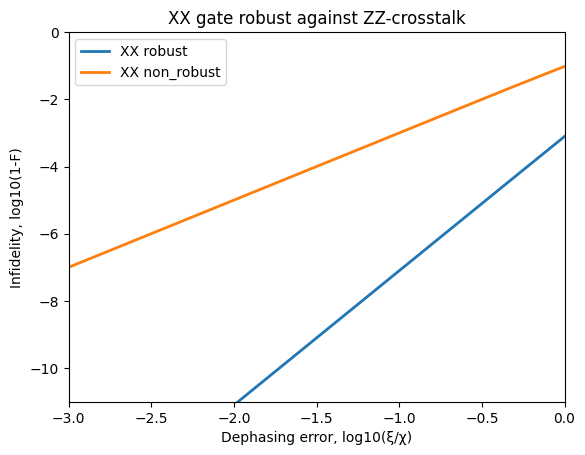

In [ ]:
fig, ax = plt.subplots()

ax.plot(np.log10(ksi_over_chi / chi), np.log10( abs(1-fid_XX_robust)), linewidth = 2, label = "XX robust")

ax.plot(np.log10(ksi_over_chi / chi), np.log10( abs(1-fid_XX_non_robust)), linewidth = 2, label = "XX non_robust")

#ax.plot(np.log10(gamma_over_chi / chi), np.log10( (gamma_over_chi/chi) **2  *8), linewidth = 2, label = "2-order")

#ax.plot(np.log10(ksi_over_chi / chi), np.log10( (ksi_over_chi/chi) **4  /1000), linewidth = 2, label = "4-order")


ax.set_xlabel("Dephasing error, log10(ξ/χ)")
ax.set_ylabel("Infidelity, log10(1-F)")
ax.set_title("XX gate robust against ZZ-crosstalk")
ax.set_ylim([-11, 0])
ax.set_xlim([-3, 0])
ax.legend();

# fig.savefig("XX_crosstalk_robust_wrt_chi.svg")